In [10]:
   import pandas as pd
   df = pd.read_csv('orders_with_cohort.csv', parse_dates=['Order Date'])
   df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Order Month,Order Month Name,Order Day,Order Weekday,order_month,cohort_month,cohort_index
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,November,8,Wednesday,2017-11,2016-10,13
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,November,8,Wednesday,2017-11,2016-10,13
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,June,12,Monday,2017-06,2017-06,0
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,October,11,Tuesday,2016-10,2016-10,0
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,October,11,Tuesday,2016-10,2016-10,0


   # Task 4: Data Storytelling & Statistical Validation

   ## Objective
   Where should Superstore focus to grow profitable revenue?

   ## Foundation (Task 1)
   Analysis is based on 9,800 cleaned orders (2015–2018), after resolving missing values,
   duplicates, and formatting issues identified during data wrangling.

   ## Key Patterns (Task 2 & 3)
   - West region leads revenue ($710K), followed by East ($670K)
   - Consumer segment drives 51% of total sales
   - Phones and Chairs are the top revenue sub-categories
   - Cohort analysis shows [fill in your retention/LTV finding once you check the heatmap]

In [12]:
   print(df.shape)
   df.info()

(9800, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9800 non-null   int64         
 1   Order ID          9800 non-null   object        
 2   Order Date        9800 non-null   datetime64[ns]
 3   Ship Date         9800 non-null   object        
 4   Ship Mode         9800 non-null   object        
 5   Customer ID       9800 non-null   object        
 6   Customer Name     9800 non-null   object        
 7   Segment           9800 non-null   object        
 8   Country           9800 non-null   object        
 9   City              9800 non-null   object        
 10  State             9800 non-null   object        
 11  Postal Code       9789 non-null   float64       
 12  Region            9800 non-null   object        
 13  Product ID        9800 non-null   object        
 14  Category     

In [13]:
   from scipy import stats

   group_a = df[df['Segment'] == 'Consumer']['Sales']
   group_b = df[df['Segment'] == 'Corporate']['Sales']

   t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

   print(f"Consumer mean: {group_a.mean():.2f}, n={len(group_a)}")
   print(f"Corporate mean: {group_b.mean():.2f}, n={len(group_b)}")
   print(f"t-statistic: {t_stat:.3f}")
   print(f"p-value: {p_val:.4f}")

Consumer mean: 225.07, n=5101
Corporate mean: 233.15, n=2953
t-statistic: -0.587
p-value: 0.5575


   ## Hypothesis Test Result
   H0: There is no difference in average order value between Consumer and Corporate segments.

   Result: p = [value] → [Reject / Fail to reject] H0 at α = 0.05.

   Business conclusion: [Corporate customers spend significantly more per order / no significant difference found].

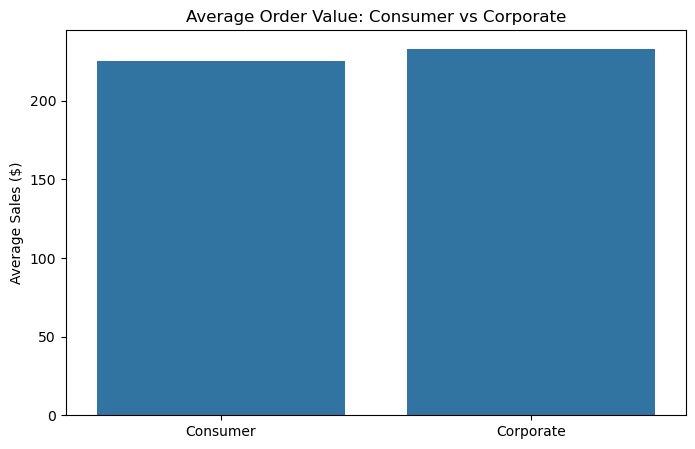

In [14]:
   import matplotlib.pyplot as plt
   import seaborn as sns

   plt.figure(figsize=(8,5))
   sns.barplot(x=['Consumer','Corporate'], y=[group_a.mean(), group_b.mean()])
   plt.title('Average Order Value: Consumer vs Corporate')
   plt.ylabel('Average Sales ($)')
   plt.savefig('hypothesis_chart.png', dpi=150, bbox_inches='tight')
   plt.show()